# Control-group persistent entropy analysis

This notebook reproduces the control-group workflow. The restricted HCP/control data are not included in the public repository. The original exploratory notebook used random subsampling without saving a seed or selected indices; this public version fixes `CONTROL_RANDOM_SEED = 42` and prints the selected subjects for reproducibility.


## Control data loading


In [1]:
# Private HCP/control-data configuration and paired loading
from pathlib import Path
import glob
import os
import numpy as np
import matplotlib.pyplot as plt

# Analysis environment used for the study: Windows 11.
# Adjust this path locally if the restricted HCP/control data are stored elsewhere.
HCP_ROOT_DIR = Path(r"D:\temp_doc\HCPYoungAdult")
PARCELLATION_FOLDER = "Schaefer2018_100Parcels_7Networks_Tian_Subcortex_S1_3T"
APPLY_INITIAL_PREPROCESSING = True


def preprocess_matrix(mat):
    """Set the main diagonal to zero, matching the original notebook."""
    mat_proc = mat.copy()
    np.fill_diagonal(mat_proc, 0)
    return mat_proc


if not HCP_ROOT_DIR.exists():
    raise FileNotFoundError(
        f"HCP_ROOT_DIR was not found: {HCP_ROOT_DIR}. "
        "Set HCP_ROOT_DIR to the private control-data folder before running this notebook."
    )

sujeitos = sorted([p.name for p in HCP_ROOT_DIR.iterdir() if p.is_dir()])
print(f"Total subject folders found: {len(sujeitos)}")
print("-" * 50)

fishbefore = []
fishafter = []
sujeitos_utilizados = []
sujeitos_descartados = []

for sujeito in sujeitos:
    rest1_dir = HCP_ROOT_DIR / sujeito / "rfMRI_REST1" / PARCELLATION_FOLDER
    rest2_dir = HCP_ROOT_DIR / sujeito / "rfMRI_REST2" / PARCELLATION_FOLDER
    busca_rest1 = sorted(rest1_dir.glob("*.txt"))
    busca_rest2 = sorted(rest2_dir.glob("*.txt"))

    tem_rest1 = len(busca_rest1) > 0
    tem_rest2 = len(busca_rest2) > 0

    if tem_rest1 and tem_rest2:
        mat1 = np.loadtxt(busca_rest1[0])
        mat2 = np.loadtxt(busca_rest2[0])

        if APPLY_INITIAL_PREPROCESSING:
            mat1 = preprocess_matrix(mat1)
            mat2 = preprocess_matrix(mat2)

        fishbefore.append(mat1)
        fishafter.append(mat2)
        sujeitos_utilizados.append(sujeito)
    else:
        faltando = []
        if not tem_rest1:
            faltando.append("REST1")
        if not tem_rest2:
            faltando.append("REST2")
        motivo = " e ".join(faltando)
        print(f"Subject {sujeito} discarded. Missing: {motivo}.")
        sujeitos_descartados.append(sujeito)

if len(fishbefore) > 0:
    before = np.array(fishbefore)
    after = np.array(fishafter)
else:
    before = np.empty((0,))
    after = np.empty((0,))

print("-" * 50)
print("\n--- Pairing report ---")
print(f"Discarded subjects without a complete pair: {len(sujeitos_descartados)}")
print(f"Successfully loaded paired subjects: {len(sujeitos_utilizados)}")
print("\n--- Loading confirmation ---")
print(f"Total before/REST1 matrices: {before.shape[0] if before.ndim > 1 else 0}")
print(f"Final before shape: {before.shape}")
print(f"Total after/REST2 matrices : {after.shape[0] if after.ndim > 1 else 0}")
print(f"Final after shape : {after.shape}")

if before.shape == after.shape and before.ndim > 1:
    print("\nSuccess: before and after matrices have paired subjects and equal dimensions.")
else:
    print("\nWarning/error: inconsistent dimensions or no data loaded.")


Total subject folders found: 1088
--------------------------------------------------
Subject 101410 discarded. Missing: REST2.
Subject 107220 discarded. Missing: REST2.
Subject 112819 discarded. Missing: REST2.
Subject 113417 discarded. Missing: REST2.
Subject 113821 discarded. Missing: REST2.
Subject 114116 discarded. Missing: REST2.
Subject 116221 discarded. Missing: REST2.
Subject 116423 discarded. Missing: REST2.
Subject 117728 discarded. Missing: REST2.
Subject 120010 discarded. Missing: REST2.
Subject 121315 discarded. Missing: REST2.
Subject 121719 discarded. Missing: REST2.
Subject 122418 discarded. Missing: REST2.
Subject 128329 discarded. Missing: REST2.
Subject 129533 discarded. Missing: REST2.
Subject 129937 discarded. Missing: REST2.
Subject 142424 discarded. Missing: REST2.
Subject 145531 discarded. Missing: REST2.
Subject 146634 discarded. Missing: REST2.
Subject 150524 discarded. Missing: REST2.
Subject 151021 discarded. Missing: REST2.
Subject 155231 discarded. Missing

## Thresholding and diagonal handling


In [2]:
import numpy as np

# ==========================================
#   CONFIGURAÇÕES DO PRÉ-PROCESSAMENTO
# ==========================================
aplicar_limiar = True       # True para LIGAR, False para DESLIGAR o threshold
valor_limiar = 0.05         # Valor do limiar (Correlações mais fracas que isso viram 0)

zerar_diagonal = True       # True para manter a diagonal principal como 0
# ==========================================


def preprocessar_matrizes(matrizes_3d, ligar_limiar, limiar, zera_diag):
    """
    Aplica o threshold e zera a diagonal de um conjunto de matrizes (Sujeitos, MatrizX, MatrizY).
    """
    # Cria uma cópia para não sobrescrever os dados originais "brutos" na memória
    matrizes_proc = matrizes_3d.copy()
    
    # 1. Aplica o Limiar (Threshold)
    if ligar_limiar:
        # Pega as correlações fracas (entre -limiar e +limiar) e transforma em 0
        # Obs: Usamos np.abs para zerar correlações fracas independente de serem positivas ou negativas
        mascara_fracas = np.abs(matrizes_proc) < limiar
        matrizes_proc[mascara_fracas] = 0.0
        
        # NOTA: Se na sua metodologia antiga você também excluía TODAS as correlações 
        # negativas, você pode trocar a linha acima por: matrizes_proc[matrizes_proc < limiar] = 0.0

    # 2. Zera a diagonal principal
    if zera_diag:
        # Como temos um array 3D (vários sujeitos), iteramos por cada sujeito para zerar a diagonal
        for i in range(matrizes_proc.shape[0]):
            np.fill_diagonal(matrizes_proc[i], 0.0)
            
    return matrizes_proc


# ==========================================
#   APLICANDO O PRÉ-PROCESSAMENTO
# ==========================================

# Verifica se as variáveis existem na memória (para evitar erros se rodar fora de ordem)
if 'before' in locals() and 'after' in locals() and before.ndim > 1:
    print("Iniciando pré-processamento...")
    
    # Gera novas variáveis para os dados processados
    before_proc = preprocessar_matrizes(before, aplicar_limiar, valor_limiar, zerar_diagonal)
    after_proc  = preprocessar_matrizes(after, aplicar_limiar, valor_limiar, zerar_diagonal)
    
    print("\n--- Relatório do Pré-processamento ---")
    print(f"Limiar aplicado: {'SIM (Valor: ' + str(valor_limiar) + ')' if aplicar_limiar else 'NÃO'}")
    
    # Vamos verificar o impacto do threshold no primeiro sujeito como exemplo
    total_elementos = before_proc[0].size
    zeros_antes = np.sum(before[0] == 0)
    zeros_depois = np.sum(before_proc[0] == 0)
    
    print(f"\nExemplo (Sujeito 1 - REST1):")
    print(f"Zeros ANTES do processamento : {zeros_antes} ({(zeros_antes/total_elementos)*100:.1f}%)")
    print(f"Zeros DEPOIS do processamento: {zeros_depois} ({(zeros_depois/total_elementos)*100:.1f}%)")
    
else:
    print("ERRO: As variáveis 'before' e 'after' não foram encontradas.")
    print("Por favor, rode o bloco de carregamento dos dados primeiro.")


Iniciando pré-processamento...

--- Relatório do Pré-processamento ---
Limiar aplicado: SIM (Valor: 0.05)

Exemplo (Sujeito 1 - REST1):
Zeros ANTES do processamento : 116 (0.9%)
Zeros DEPOIS do processamento: 2304 (17.1%)


## Deterministic subsampling


In [3]:
import numpy as np

# ==========================================
#   CONTROL-GROUP SUBSAMPLING CONFIGURATION
# ==========================================
aplicar_subamostragem = True
num_sujeitos_desejado = 10

# The original exploratory notebook did not save the random seed, selected indices,
# or NumPy random state. Therefore the exact original random draw cannot be recovered
# from the notebook alone. This version fixes a seed and prints the selected subjects.
CONTROL_RANDOM_SEED = 42
CONTROL_SELECTED_INDICES = None  # Optional: replace with a list of fixed indices to reproduce an archived draw.

# ==========================================
#   APPLY SUBSAMPLING
# ==========================================
if 'before' in locals() and 'after' in locals() and before.ndim > 1:
    total_sujeitos_atual = before.shape[0]

    print("--- Starting control-group subsampling ---")

    if aplicar_subamostragem:
        if num_sujeitos_desejado >= total_sujeitos_atual:
            print(f"Warning: requested n={num_sujeitos_desejado} is >= available n={total_sujeitos_atual}.")
            print("No exclusion was performed.")
            indices_selecionados = np.arange(total_sujeitos_atual)
        else:
            if CONTROL_SELECTED_INDICES is None:
                np.random.seed(CONTROL_RANDOM_SEED)
                indices_selecionados = np.random.choice(
                    total_sujeitos_atual,
                    size=num_sujeitos_desejado,
                    replace=False,
                )
            else:
                indices_selecionados = np.asarray(CONTROL_SELECTED_INDICES, dtype=int)
                if len(indices_selecionados) != num_sujeitos_desejado:
                    raise ValueError("CONTROL_SELECTED_INDICES length must match num_sujeitos_desejado.")

            indices_selecionados.sort()
            sujeitos_subamostrados = [sujeitos_utilizados[i] for i in indices_selecionados]

            before = before[indices_selecionados]
            after = after[indices_selecionados]

            print("Status: enabled")
            print(f" - Random seed: {CONTROL_RANDOM_SEED if CONTROL_SELECTED_INDICES is None else 'manual indices'}")
            print(f" - Original subjects: {total_sujeitos_atual}")
            print(f" - Retained subjects: {len(indices_selecionados)}")
            print(f" - Excluded subjects: {total_sujeitos_atual - len(indices_selecionados)}")
            print(f" - Selected indices: {indices_selecionados.tolist()}")
            print(f" - Selected subjects: {sujeitos_subamostrados}")
    else:
        indices_selecionados = np.arange(total_sujeitos_atual)
        sujeitos_subamostrados = list(sujeitos_utilizados)
        print("Status: disabled. Keeping all original subjects unchanged.")

    print("\n--- Current dimensions ---")
    print(f"Updated before shape: {before.shape}")
    print(f"Updated after shape : {after.shape}")
else:
    print("ERROR: before and after variables were not found in memory.")


--- Starting control-group subsampling ---
Status: enabled
 - Random seed: 42
 - Original subjects: 1018
 - Retained subjects: 10
 - Excluded subjects: 1008
 - Selected indices: [31, 136, 298, 398, 528, 587, 597, 730, 914, 946]
 - Selected subjects: ['106521', '130518', '164131', '187850', '227432', '310621', '325129', '558657', '826454', '877269']

--- Current dimensions ---
Updated before shape: (10, 116, 116)
Updated after shape : (10, 116, 116)


## Persistent entropy and statistics


In [4]:
def c_estat(before, after, dim):
        print('DIMENSÃO '+str(dim))
        print('Teste de Normalidade')
        print('Shapiro_before: '+str(scipy.stats.shapiro(before)))
        print('Shapiro_after: '+str(scipy.stats.shapiro(after)))
        print('Teste paramétricos e não-paramétricos')
        print('Ranksum: '+str(scipy.stats.ranksums(before, after)))
        print('Wilcoxon: '+str(scipy.stats.wilcoxon(before, after)))
        print('Paired T-Test: '+str(scipy.stats.ttest_rel(before, after)))

def c_metrics(before,after, suj):
        print('Subject'+str(suj+1))
        print('Kurtosis_before: '+str(scipy.stats.kurtosis(before)))
        print('Kurtosis_after: '+str(scipy.stats.kurtosis(after)))
        print('Skewness_before: '+str(scipy.stats.skew(before)))
        print('Skewness_after: '+str(scipy.stats.skew(after)))
        print('\n')  


C:\ProgramData\anaconda3\Lib\site-packages\gudhi\persistence_graphical_tools.py:129: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")


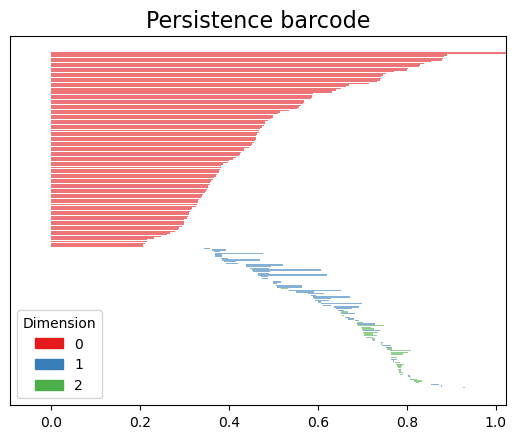

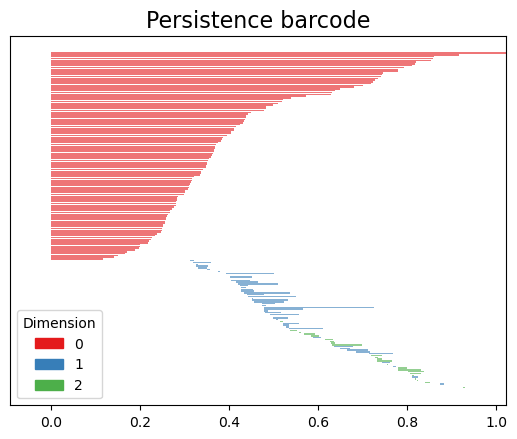

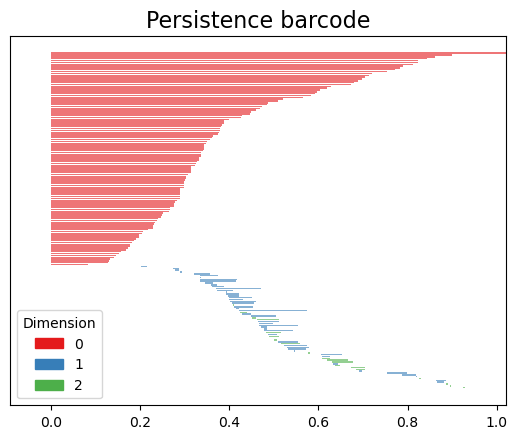

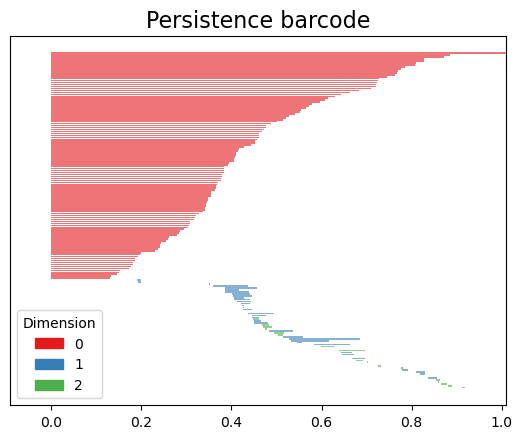

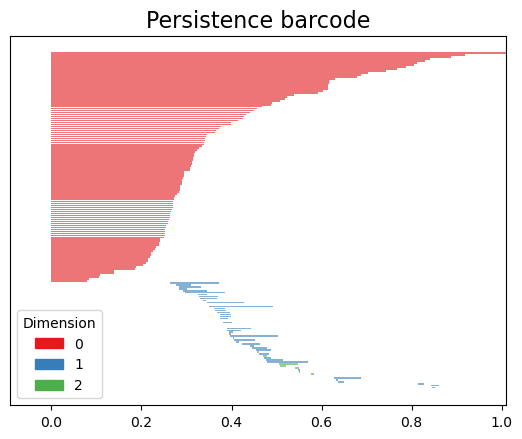

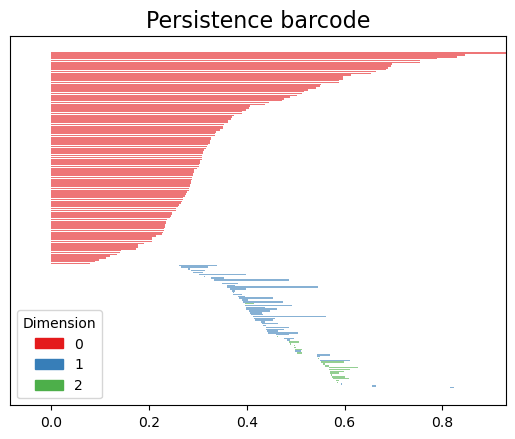

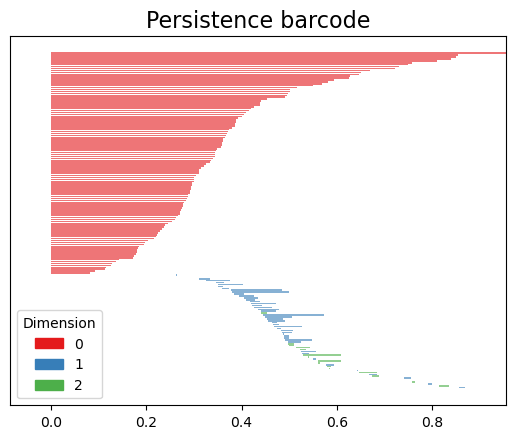

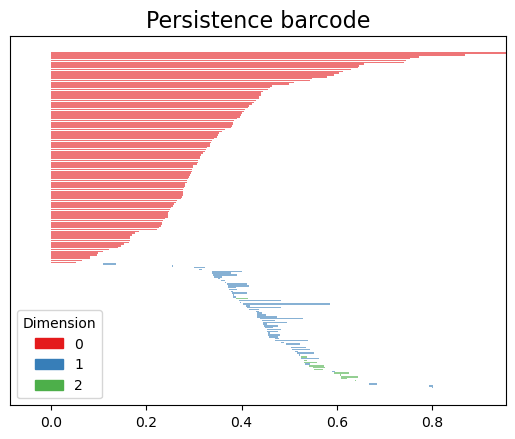

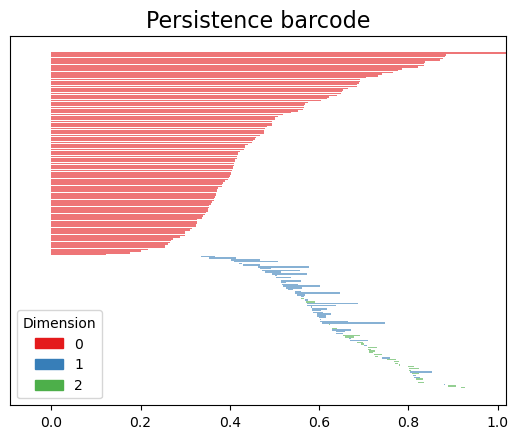

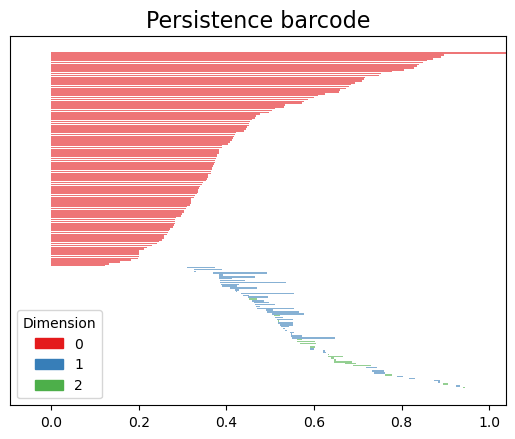

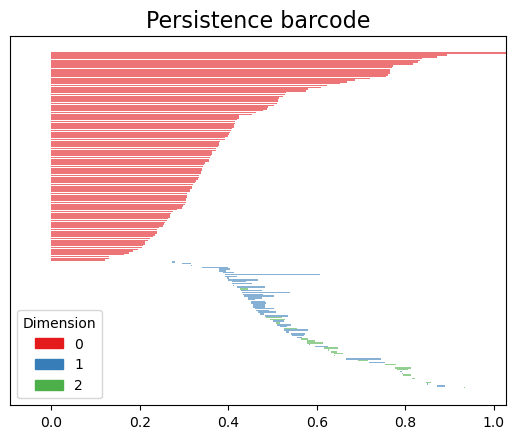

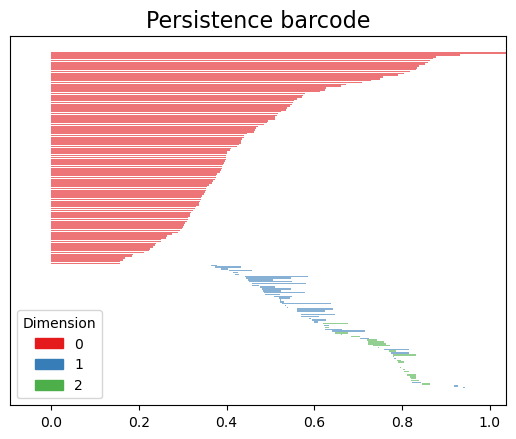

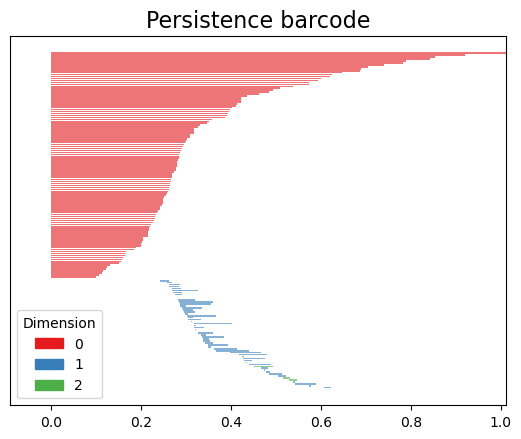

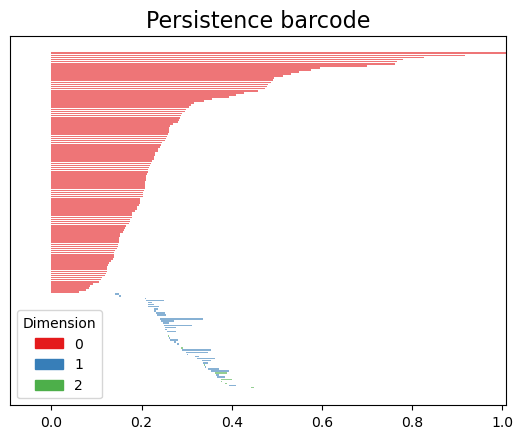

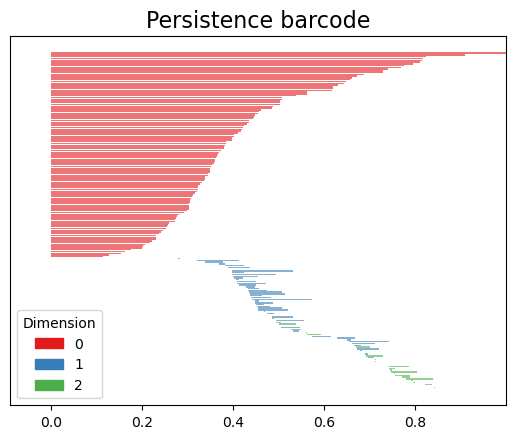

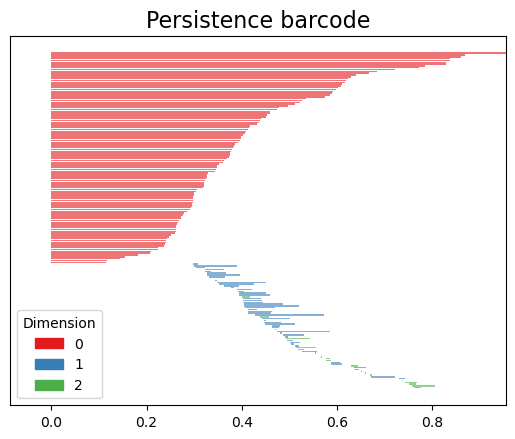

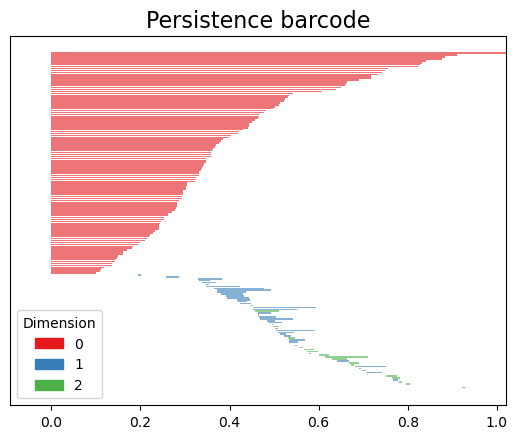

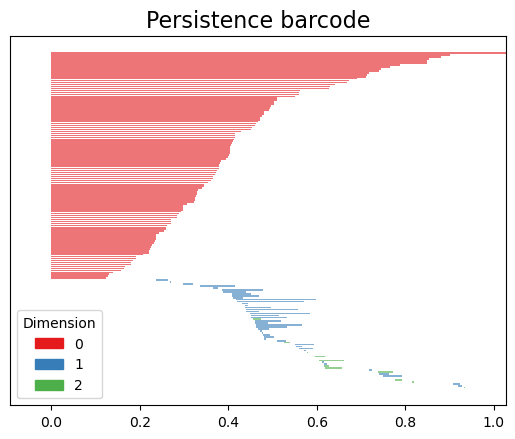

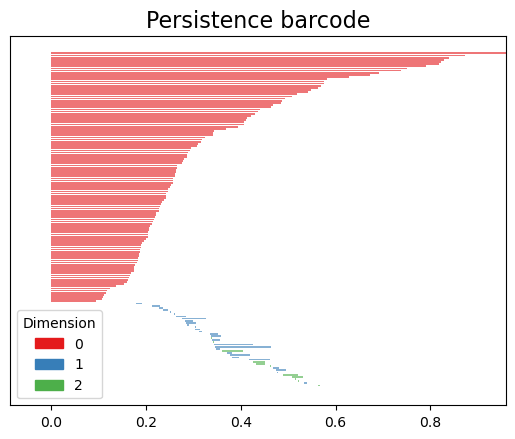

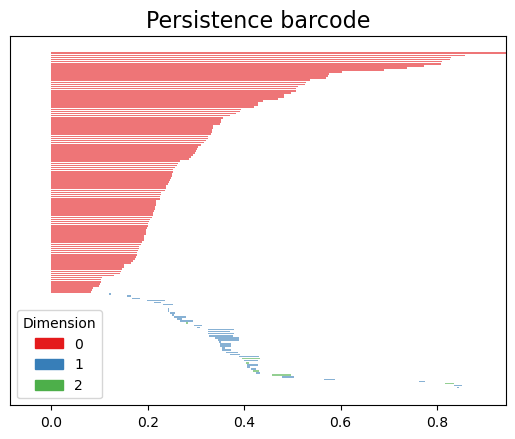

[np.float64(3.4926925181572845), np.float64(2.9662355120491197), np.float64(2.1847309341227192), np.float64(2.694916826328595), np.float64(3.2891874643607566), np.float64(3.1183302216973106), np.float64(1.3825638035784589), np.float64(3.206766239422297), np.float64(2.9822396268825546), np.float64(2.385044334889046)]
[np.float64(3.1653831311558336), np.float64(2.806049106560967), np.float64(3.0392982693821633), np.float64(2.5587746718886812), np.float64(2.8745249770326664), np.float64(3.255120907800527), np.float64(2.0664798912045725), np.float64(2.6901457545059135), np.float64(2.4677251056716094), np.float64(1.8716696127786507)]
DIMENSÃO 0
Teste de Normalidade
Shapiro_before: ShapiroResult(statistic=np.float64(0.9005039833707816), pvalue=np.float64(0.22190375048297))
Shapiro_after: ShapiroResult(statistic=np.float64(0.9491972044768872), pvalue=np.float64(0.6590112163513678))
Teste paramétricos e não-paramétricos
Ranksum: RanksumsResult(statistic=np.float64(0.7559289460184545), pvalue=n

In [5]:
# Cálculo entropia persistente

import gudhi
import scipy
from gudhi import representations

def c_pers(matrix):
    dist_matrix = 1 - np.abs(matrix)
    scomplex = gudhi.RipsComplex(distance_matrix=dist_matrix, max_edge_length=0.99)

    s_tree = scomplex.create_simplex_tree(max_dimension=3)

    a = s_tree.persistence(homology_coeff_field=2, min_persistence=0)
    b = s_tree.persistence_intervals_in_dimension(2)
    
    gudhi.plot_persistence_barcode(a,legend=True)
    plt.show()

    sum=0
    for i in range(0,len(b)):
        if b[i][1] < float('inf'):
            sum += b[i][1]

    entropy = 0
    for i in range(0,len(b)):
        if b[i][1] < float('inf'):        
            entropy += -(b[i][1]/sum)*np.log(b[i][1]/sum)
    
    return entropy

antes = []
depois = []

for i in range(0,len(before)):
    if len(before)==len(after):
        antes.append(c_pers(before[i]))
        depois.append(c_pers(after[i]))

print(antes)
print(depois)

c_estat(antes,depois,0)


In [6]:
# Cálculo entropia persistente

import gudhi
import scipy
import numpy as np
import matplotlib.pyplot as plt
from gudhi import representations

# Alteração: Adicionado o parametro 'dim'
def c_pers(matrix, dim):
    dist_matrix = 1 - np.abs(matrix)
    scomplex = gudhi.RipsComplex(distance_matrix=dist_matrix, max_edge_length=0.99)

    # Alteração: Aumentado para 4 para permitir o cálculo da dimensão 3
    s_tree = scomplex.create_simplex_tree(max_dimension=4)

    a = s_tree.persistence(homology_coeff_field=2, min_persistence=0)
    
    # Alteração: Usa a dimensão passada como argumento
    b = s_tree.persistence_intervals_in_dimension(dim)
    
    gudhi.plot_persistence_barcode(a, legend=True)
    
    # Alteração: Desabilitado show e adicionado close para não acumular memória
    # plt.show()
    plt.close()

    # Lógica original mantida
    soma = 0
    for i in range(0, len(b)):
        if b[i][1] < float('inf'):
            soma += b[i][1]

    entropy = 0
    # Adicionei verificação simples para evitar divisão por zero se a soma for 0
    if soma > 0:
        for i in range(0, len(b)):
            if b[i][1] < float('inf'):        
                entropy += -(b[i][1]/soma)*np.log(b[i][1]/soma)
    
    return entropy

antes = []
depois = []

if len(before) == len(after):
    for i in range(0, len(before)):
        # Vetores temporários para este sujeito
        sujeito_antes_dims = []
        sujeito_depois_dims = []
        
        # Loop externo solicitando as dimensões 0, 1, 2 e 3
        for d in range(4):
            sujeito_antes_dims.append(c_pers(before[i], d))
            sujeito_depois_dims.append(c_pers(after[i], d))
        
        # Adiciona o vetor [d0, d1, d2, d3] à lista principal
        antes.append(sujeito_antes_dims)
        depois.append(sujeito_depois_dims)

print(antes)
print(depois)

# Atenção: Se c_estat esperar vetores simples, você precisará adaptá-la
# ou chamar passando uma coluna específica, ex: c_estat([x[0] for x in antes], [y[0] for y in depois], 0)
# c_estat(antes,depois,0)


[[np.float64(4.676159823623071), np.float64(3.905858513846469), np.float64(3.4926925181572845), np.float64(3.25690983221788)], [np.float64(4.625568537609088), np.float64(3.8052474552616586), np.float64(2.9662355120491197), np.float64(1.6052206400610198)], [np.float64(4.632260171295415), np.float64(3.7693270893831756), np.float64(2.1847309341227192), np.float64(0.6927480388761994)], [np.float64(4.6401560600730365), np.float64(3.7780763219431868), np.float64(2.694916826328595), np.float64(1.7785829957451478)], [np.float64(4.681126053697888), np.float64(3.8760838554175416), np.float64(3.2891874643607566), np.float64(2.8861495004314586)], [np.float64(4.6504392541282895), np.float64(3.83755217809694), np.float64(3.1183302216973106), np.float64(1.9436026155879587)], [np.float64(4.622457670389753), np.float64(3.939071137720987), np.float64(1.3825638035784589), np.float64(1.3698572408367766)], [np.float64(4.660777262333218), np.float64(3.8713926609847706), np.float64(3.206766239422297), np.flo

In [7]:
import scipy.stats
import numpy as np

# 1. Sua função c_estat original
def c_estat(before, after, dim):
    print('\n' + '='*40)
    print('DIMENSÃO ' + str(dim))
    print('='*40)
    
    print('--- Teste de Normalidade ---')
    # O try/except evita que o código pare se todos os números forem iguais (variância zero)
    try:
        print('Shapiro_before: ' + str(scipy.stats.shapiro(before)))
        print('Shapiro_after: ' + str(scipy.stats.shapiro(after)))
    except Exception as e:
        print(f"Erro no Shapiro: {e}")

    print('\n--- Testes paramétricos e não-paramétricos ---')
    print('Ranksum: ' + str(scipy.stats.ranksums(before, after)))
    
    # Wilcoxon pode falhar se a diferença for zero em todos os casos, adicionado proteção
    try:
        print('Wilcoxon: ' + str(scipy.stats.wilcoxon(before, after)))
    except ValueError:
        print("Wilcoxon: Não foi possível calcular (diferenças zero ou tamanho insuficiente).")
        
    print('Paired T-Test: ' + str(scipy.stats.ttest_rel(before, after)))

# 2. Loop para processar as 4 dimensões (0, 1, 2, 3)
# Considera que 'antes' e 'depois' são listas de listas: [[d0, d1, d2, d3], [d0, d1, d2, d3], ...]

dimensoes_para_analisar = 4

for dim in range(dimensoes_para_analisar):
    # List comprehension para extrair a coluna da dimensão atual
    # Pega o índice [dim] de cada sujeito na lista 'antes'
    dados_antes_dim = [sujeito[dim] for sujeito in antes]
    
    # Pega o índice [dim] de cada sujeito na lista 'depois'
    dados_depois_dim = [sujeito[dim] for sujeito in depois]
    
    # Chama a função estatística para essa dimensão específica
    c_estat(dados_antes_dim, dados_depois_dim, dim)



DIMENSÃO 0
--- Teste de Normalidade ---
Shapiro_before: ShapiroResult(statistic=np.float64(0.955762252973207), pvalue=np.float64(0.7366847098744006))
Shapiro_after: ShapiroResult(statistic=np.float64(0.7958372425300195), pvalue=np.float64(0.012903835082136906))

--- Testes paramétricos e não-paramétricos ---
Ranksum: RanksumsResult(statistic=np.float64(-0.22677868380553634), pvalue=np.float64(0.8205958397554409))
Wilcoxon: WilcoxonResult(statistic=np.float64(23.0), pvalue=np.float64(0.6953125))
Paired T-Test: TtestResult(statistic=np.float64(0.5061607310544588), pvalue=np.float64(0.6249092124353908), df=np.int64(9))

DIMENSÃO 1
--- Teste de Normalidade ---
Shapiro_before: ShapiroResult(statistic=np.float64(0.7782108561775177), pvalue=np.float64(0.007873526085713472))
Shapiro_after: ShapiroResult(statistic=np.float64(0.9313610019321921), pvalue=np.float64(0.46141199923263726))

--- Testes paramétricos e não-paramétricos ---
Ranksum: RanksumsResult(statistic=np.float64(0.453557367611072

In [8]:
import pingouin as pg
import pandas as pd

# Garante que o Pandas mostre todas as colunas no print (opcional, mas ajuda a ver o resultado)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("=== ANÁLISE ESTATÍSTICA POR DIMENSÃO (WILCOXON) ===\n")

# Loop para as 4 dimensões (0, 1, 2, 3)
for dim in range(4):
    print(f"{'='*20} DIMENSÃO {dim} {'='*20}")
    
    # 1. Preparação dos dados: Extrai a coluna da dimensão atual de todos os sujeitos
    # Transformamos a lista de listas em dois vetores simples para aquela dimensão
    try:
        dados_antes_dim = [sujeito[dim] for sujeito in antes]
        dados_depois_dim = [sujeito[dim] for sujeito in depois]
        
        # 2. Execução do teste usando Pingouin
        # alternative='two-sided' é o padrão (bilateral)
        res = pg.wilcoxon(dados_antes_dim, dados_depois_dim)
        
        # 3. Exibição dos resultados
        print(res)
        print("\n") # Pula uma linha para organizar
        
    except IndexError:
        print(f"Erro: Não foi possível acessar dados para a dimensão {dim}. Verifique se 'antes' e 'depois' foram calculados corretamente.")
    except Exception as e:
        print(f"Erro ao calcular estatística para dimensão {dim}: {e}")


=== ANÁLISE ESTATÍSTICA POR DIMENSÃO (WILCOXON) ===

==================== DIMENSÃO 0 ====================
          W_val alternative     p_val       RBC  CLES
Wilcoxon   23.0   two-sided  0.695312  0.163636  0.47


==================== DIMENSÃO 1 ====================
          W_val alternative  p_val       RBC  CLES
Wilcoxon   27.0   two-sided    1.0 -0.018182  0.56


==================== DIMENSÃO 2 ====================
          W_val alternative     p_val       RBC  CLES
Wilcoxon   21.0   two-sided  0.556641  0.236364   0.6


==================== DIMENSÃO 3 ====================
          W_val alternative     p_val       RBC  CLES
Wilcoxon   16.0   two-sided  0.275391  0.418182   0.6


